# **Analisis Sinkronisasi Pengiriman dan Perakitan Furnitur - Dekoruma**

**Muhammad Arief Setiawan** 
- Capstone Project Module 3 
- Purwadhika Digital School
- Audiens utama analisis ini adalah **Head of Operations**.

# 1. Latar Belakang

Dekoruma adalah peritel *Home & Living* yang menjual furnitur lewat aplikasi, website, dan 38
toko fisik (*Dekoruma Experience Center*).

Berbeda dari barang kecil, satu pesanan furnitur tidak selesai dalam satu kali kedatangan,
melainkan **dua**: truk mengantar barangnya, lalu tim tukang datang merakitnya. Dua kedatangan
berarti dua jadwal yang harus diselaraskan — dan di situlah letak kerentanannya.

Ketika keduanya tidak sinkron, pelanggan menunggu berhari-hari dengan kardus menumpuk di rumah.
Ketika tukang akhirnya datang pun, perakitan masih bisa gagal karena komponen kurang atau panel
rusak. Setiap kegagalan berarti perjalanan tukang yang terbuang dan pelanggan yang menunggu lebih
lama.

# 2. Pernyataan Masalah

Tim Operations Dekoruma ingin mengetahui **seberapa buruk sinkronisasi jadwal pengiriman dan
perakitan, dan apa penyebabnya**, agar bisa menentukan perbaikan yang tepat sasaran.

Sebagai *data analyst*, kita akan menjawab lima pertanyaan berikut:

1. Berapa **rata-rata selisih hari** antara barang tiba dan tukang datang merakit?
2. **Kategori furnitur apa** yang paling sering gagal dirakit?
3. **Seberapa berantakan** pencatatan kategori furnitur, dan bagaimana menstandarisasinya?
4. Berapa banyak pesanan yang **tanggal perakitannya mendahului** tanggal barang tiba?
5. Berapa banyak **nilai biaya perakitan yang tidak wajar**, dan dari mana asalnya?

# 3. Data

Dataset terdiri dari tiga tabel yang saling terhubung:

| Tabel | Isi | Kunci |
|---|---|---|
| dekoruma_orders | catatan pesanan dan perakitan | order_id |
| dekoruma_products | daftar produk dan kategorinya | sku_id |
| dekoruma_stores | daftar saluran penjualan | store_id |

orders adalah **tabel fakta** — mencatat kejadian. Dua lainnya **tabel dimensi** — hanya
menerangkan. Artinya jumlah baris di products dan stores bukan jumlah penjualan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, normaltest

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
# baca ketiga tabel
orders = pd.read_csv('../input/dataset/dekoruma_orders.csv')
products = pd.read_csv('../input/dataset/dekoruma_products.csv')
stores = pd.read_csv('../input/dataset/dekoruma_stores.csv')

print('orders:',orders.shape)
print('products:',products.shape)
print('stores:',stores.shape)

orders: (300000, 9)
products: (1500, 4)
stores: (40, 3)


orders 300.000 baris, products 1.500 baris, stores 40 baris.

# 4. Data Understanding

Sebelum membersihkan apa pun, saya perlu tahu temuan apa saja yang bisa ditemukan. saya periksa ketiga
tabel satu per satu

## 4.1 Tabel products

Mari kita lihat isi tabel produk. Tiga hal yang ingin kita ketahui:

* Apa saja kolomnya, dan berapa nilai kosongnya?
* Kolom mana yang berperan sebagai penanda unik, dan mana yang pengelompok?
* Apakah isi kolom category sudah konsisten?

In [3]:
products.head()

,sku_id,product_name,category,is_assembly_required
0,SKU-FURN-00001,Furnitur Kayu Olahan 407,Office Chair,True
1,SKU-FURN-00002,Furnitur Kayu Olahan 536,Wardrobe,True
2,SKU-FURN-00003,Sofa Japandi Minimalis 867,Sofa,True
3,SKU-FURN-00004,Furnitur Kayu Olahan 727,Kursi Kerja,True
4,SKU-FURN-00005,Furnitur Kayu Olahan 363,Wardrobe,True


In [4]:
# ukuran, tipe data, dan nilai kosong
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   sku_id                1500 non-null   str  
 1   product_name          1500 non-null   str  
 2   category              1500 non-null   str  
 3   is_assembly_required  1500 non-null   bool 
dtypes: bool(1), str(3)
memory usage: 106.5 KB


In [5]:
# jumlah nilai unik dan contoh isinya di tiap kolom
ringkasan = []
for kolom in products.columns:
    ringkasan.append([kolom,
                      products[kolom].isna().sum(),
                      products[kolom].nunique(),
                      products[kolom].unique()[:3]])

pd.DataFrame(ringkasan, columns=['Kolom', 'Kosong', 'Nilai Unik', 'Contoh'])

pd.DataFrame({'Kosong': products.isna().sum(),
              'Nilai Unik': products.nunique()})

,Kosong,Nilai Unik
sku_id,0,1500
product_name,0,918
category,0,11
is_assembly_required,0,2


Tabel products berisi **1.500 baris x 4 kolom**, **tanpa nilai kosong sama sekali**

* sku_id punya 1.500 nilai unik — sama dengan jumlah baris, jadi ini **penanda unik** sekaligus
  kunci penghubung ke orders
* category hanya punya 11 nilai — ini **kolom pengelompok utama**, dan seluruh analisis
  kegagalan nanti bersandar padanya
* Dari contoh isinya sudah terlihat campur bahasa: Office Chair, Wardrobe, Sofa. Ini
  petunjuk pertama bahwa penamaannya bermasalah

In [6]:
# daftar kategori beserta jumlah produknya
products['category'].value_counts()

category
Dekorasi        215
Sofa            214
Kursi Kerja     170
Office Chair    160
Lemari          153
Meja Makan      150
Wardrobe        125
Dining Table     84
sofabed          81
Bed              78
lmri             70
Name: count, dtype: int64

Terlihat jelas masalahnya. Ada **tiga pasang label yang menunjuk barang sama**:

| Pasangan | Masalah |
|---|---|
| Kursi Kerja (170) & Office Chair (160) | terjemahan — barang sama, dua bahasa |
| Meja Makan (150) & Dining Table (84) | terjemahan — barang sama, dua bahasa |
| Lemari (153) & lmri (70) | salah ketik |

Ditambah satu penulisan tidak rapi: sofabed (81).

Sebelum memutuskan digabung atau tidak?

In [7]:
# buang angka di akhir nama produk, sisakan polanya saja
pola_nama = products['product_name'].str.replace(r' \d+$', '', regex=True)
print('Jumlah pola nama produk:', pola_nama.nunique())

pd.crosstab(products['category'], pola_nama)

Jumlah pola nama produk: 3


product_name,Furnitur Kayu Olahan,Hiasan Meja / Karpet Aesthetic,Sofa Japandi Minimalis
category,,,
Bed,78,0,0
Dekorasi,0,215,0
Dining Table,84,0,0
Kursi Kerja,170,0,0
Lemari,153,0,0
Meja Makan,150,0,0
Office Chair,160,0,0
Sofa,0,0,214
Wardrobe,125,0,0


Hanya ada **3 pola nama untuk 11 kategori**. Furnitur Kayu Olahan dipakai bersama oleh
Bed, Meja Makan, dan Wardrobe — tiga barang yang jelas berbeda.

Artinya nama produk hanya menerangkan **bahan**, bukan jenis barang. Kolom ini tidak bisa
dijadikan bukti untuk memisahkan maupun menggabungkan kategori. Keputusan standarisasi harus
diambil berdasarkan **pengetahuan tentang barangnya**, dan karena itu alasannya wajib ditulis
terbuka.

Satu kolom lagi yang perlu dikenali sebelum lanjut: is_assembly_required.

In [8]:
# apakah semua produk dalam satu kategori sama-sama butuh dirakit?
pd.crosstab(products['category'], products['is_assembly_required'])

is_assembly_required,False,True
category,,
Bed,0,78
Dekorasi,215,0
Dining Table,0,84
Kursi Kerja,0,170
Lemari,0,153
Meja Makan,0,150
Office Chair,0,160
Sofa,124,90
Wardrobe,0,125


Ada tiga:

* **Delapan kategori seluruhnya butuh dirakit**
* **Dekorasi seluruhnya tidak butuh dirakit** (215 produk) 
* **Sofa dan sofabed bercampur** — sebagian butuh, sebagian tidak

## 4.2 Tabel stores

Melihat table store untuk melakukan pengecekan pada tabel ini apakah bisa ada sesuatu atau tidak

In [9]:
stores.head()

,store_id,store_name,channel_type
0,DKR-001,DEC Alam Sutera 1,Physical Store
1,DKR-002,DEC Bintaro 2,Physical Store
2,DKR-003,DEC Kemang 3,Physical Store
3,DKR-004,DEC Kelapa Gading 4,Physical Store
4,DKR-005,DEC Medan 5,Physical Store


In [10]:
# tabel ini kecil, jadi seluruh isinya bisa diperiksa sekaligus
print('Ukuran:', stores.shape, '| nilai kosong:', stores.isna().sum().sum())
stores['channel_type'].value_counts()

Ukuran: (40, 3) | nilai kosong: 0


channel_type
Physical Store    38
Mobile App         1
Web                1
Name: count, dtype: int64

Ternyata tabel ini **bukan daftar toko, melainkan daftar saluran penjualan**: 38 toko fisik +
1 Mobile App + 1 Website

Sekarang akan melakukan cek pola nama tokonya.

In [11]:
# pola nama toko fisik
stores[stores['channel_type'] == 'Physical Store']['store_name'].head()

0      DEC Alam Sutera 1
1          DEC Bintaro 2
2           DEC Kemang 3
3    DEC Kelapa Gading 4
4            DEC Medan 5
Name: store_name, dtype: str

## 4.3 Tabel orders

Ini tabel utama analisis kita. Empat hal yang ingin kita ketahui:

* Apa saja kolomnya, dan bagaimana format tanggalnya?
* Kolom mana yang punya nilai kosong, dan berapa banyak?
* Adakah duplikat?
* Bagaimana sebaran biaya perakitannya?

In [12]:
orders.head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,8/10/2023 17:00,8/14/2023 17:00,TUKANG-0882,8/18/2023 17:00,Success,120000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,1/30/2023 10:00,2/2/2023 10:00,TUKANG-0560,2/2/2023 10:00,Success,110000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,7/13/2023 20:00,7/19/2023 20:00,TUKANG-0631,7/24/2023 20:00,Success,230000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,9/27/2023 19:00,10/2/2023 19:00,TUKANG-0484,10/4/2023 19:00,Success,100000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,12/15/2023 12:00,12/22/2023 12:00,NaN,NaN,No Assembly Service,0


In [13]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   order_id             300000 non-null  str  
 1   store_id             300000 non-null  str  
 2   sku_id               300000 non-null  str  
 3   order_date           300000 non-null  str  
 4   delivery_date        300000 non-null  str  
 5   installer_id         190275 non-null  str  
 6   installation_date    190275 non-null  str  
 7   installation_status  300000 non-null  str  
 8   assembly_fee         300000 non-null  int64
dtypes: int64(1), str(8)
memory usage: 48.1 MB


In [14]:
# jumlah dan persentase nilai kosong
kosong = pd.DataFrame({'Kosong': orders.isna().sum(),
                       'Persen': (orders.isna().sum() / len(orders) * 100).round(2)})
kosong

,Kosong,Persen
order_id,0,0.00
store_id,0,0.00
sku_id,0,0.00
order_date,0,0.00
delivery_date,0,0.00
installer_id,109725,36.58
installation_date,109725,36.58
installation_status,0,0.00
assembly_fee,0,0.00


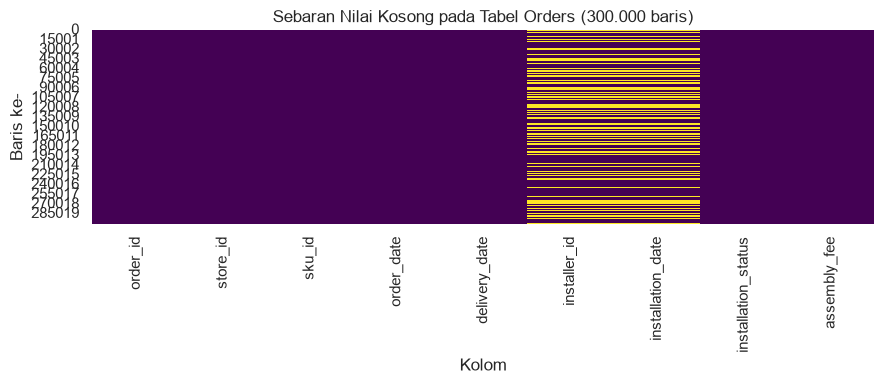

In [15]:
# sebaran nilai kosong di seluruh baris
plt.figure(figsize=(9, 4))
sns.heatmap(orders.isna(), cbar=False, cmap='viridis')
plt.title('Sebaran Nilai Kosong pada Tabel Orders (300.000 baris)')
plt.xlabel('Kolom')
plt.ylabel('Baris ke-')
plt.tight_layout()
plt.show()

Dua kolom kosong dengan proporsi sama persis: **109.725 baris (36,58%)**.

Dari heatmap, garis terangnya **berpasangan di ketinggian yang sama** dan tersebar merata dari atas sampai bawah, ini petunjuk kuat bahwa keduanya kosong
karena **satu sebab yang sama**, bukan akibat gangguan sistem 

Penyebabnya akan kita diagnosis di tahap cleaning

In [16]:
# duplikat baris penuh dan order_id kembar
print('Baris duplikat penuh :', orders.duplicated().sum())
print('order_id kembar :', orders['order_id'].duplicated().sum())

Baris duplikat penuh : 0
order_id kembar : 0


In [17]:
# sebaran biaya perakitan
orders['assembly_fee'].describe()

count    3.000000e+05
mean     4.044456e+05
std      5.557956e+06
min     -1.500000e+05
25%      0.000000e+00
50%      9.000000e+04
75%      1.700000e+05
max      9.990000e+07
Name: assembly_fee, dtype: float64

Tidak ada duplikat sama sekali, order_id sebagai penanda unik

Tapi assembly_fee bermasalah, dan bisa dibaca langsung dari angka di atas:

* Nilai terkecil **−150.000** — biaya tidak mungkin negatif
* Nilai terbesar **99.900.000** — sekitar **1.110 kali** nilai tengahnya (90.000)
* Rata-rata (404.446) jauh melampaui nilai tengah (90.000)

saya akan periksa urutan tanggalnya
**pesan → barang tiba → tukang merakit**

In [18]:
# konversi tanggal hanya untuk pemeriksaan
cek = orders[['order_date', 'delivery_date', 'installation_date']].apply(pd.to_datetime)

print('barang tiba sebelum dipesan :', (cek['delivery_date'] < cek['order_date']).sum())
print('tukang merakit sebelum barang tiba :', (cek['installation_date'] < cek['delivery_date']).sum())

barang tiba sebelum dipesan : 0
tukang merakit sebelum barang tiba : 4570


Arah pertama bersih sepenuhnya: **0** pesanan yang barangnya tiba sebelum dipesan.

Tapi ada **4.570 pesanan** yang tanggal perakitannya **mendahului** tanggal barang tiba. Tukang
tercatat merakit barang yang belum sampai — mustahil terjadi.

Perhatikan bahwa konversi tanggal di atas dilakukan pada **salinan sementara** bernama cek.
Tabel orders asli belum kita sentuh sama sekali.

## 4.4 Daftar anomali yang ditemukan

Inilah yang kita temukan, beserta rencana penanganannya:

| No | Anomali | Jumlah | Tabel |
|---|---|---|---|
| 1 | Kategori tidak standar (11 label untuk 8 jenis barang) | 4 label | products |
| 2 | installer_id & installation_date kosong | 109.725 (36,58%) | orders |
| 3 | Tanggal perakitan mendahului pengiriman | 4.570 | orders |
| 4 | assembly_fee negatif dan ekstrem | belum dihitung | orders |
| 5 | Kolom tanggal masih bertipe teks | 3 kolom | orders |

Tidak ada duplikat di tabel mana pun, dan stores sepenuhnya bersih

# 5. Data Cleaning

Kelima anomali kita tangani satu per satu. Urutannya disengaja: **kategori dibersihkan lebih
dulu** selagi masih di tabel products yang hanya 1.500 baris — kalau digabung dulu, pekerjaan
yang sama harus dilakukan pada 300.000 baris untuk hasil yang sama persis.

Aturan yang dipegang sepanjang bagian ini:

 **Salin dulu, baru bersihkan.** Data asli tidak pernah disentuh, sehingga kita selalu bisa
 membandingkan sebelum–sesudah, dan bisa mengulang dari awal kalau sebuah keputusan ternyata
 keliru.

## 5.1 Kategori tidak standar

saya sudah tahu ada empat label bermasalah. Sekarang kita putuskan mana yang digabung
dan mana yang tidak

- Digabungkan bila dua kategori hanya berbeda **cara penulisannya**

- Dipisahkan bila keduanya berbeda **cakupan** atau **fungsi barangnya**

| Kategori asal | Menjadi | Alasan |
|---|---|---|
| Office Chair | Kursi Kerja | terjemahan langsung, barang sama |
| Dining Table | Meja Makan | terjemahan langsung, barang sama |
| lmri | Lemari | salah ketik |
| sofabed | Sofa Bed | penulisan dirapikan, **tetap terpisah** dari Sofa |
| Wardrobe | *tetap* | **dipisah** dari Lemari — wardrobe khusus pakaian, lemari umum |
| Sofa | *tetap* | **dipisah** dari Sofa Bed — sofa bed bisa dibentangkan |

Label yang dipertahankan dipilih yang **paling banyak dipakai** (Kursi Kerja 170  Office
Chair 160), supaya sesedikit mungkin baris yang berubah.

In [19]:
# menggunakan tabel yang baru
products_clean = products.copy()

# peta perubahan label
peta = {'Office Chair':'Kursi Kerja',
        'Dining Table':'Meja Makan',
        'lmri':'Lemari',
        'sofabed': 'Sofa Bed'}

products_clean['category'] = products_clean['category'].replace(peta)

In [20]:
# cek hasilnya
print('Kategori sebelum :', products['category'].nunique())
print('Kategori sesudah :', products_clean['category'].nunique())
products_clean['category'].value_counts()

Kategori sebelum : 11
Kategori sesudah : 8


category
Kursi Kerja    330
Meja Makan     234
Lemari         223
Dekorasi       215
Sofa           214
Wardrobe       125
Sofa Bed        81
Bed             78
Name: count, dtype: int64

**11 kategori menjadi 8.** Tidak ada produk yang hilang — totalnya tetap 1.500, hanya labelnya
yang dipindahkan.

pertanyaannya adalah apakah pembersihan ini benar-benar berpengaruh, atau sekadar merapikan
tampilan? Mari kita bandingkan **jumlah pesanan** per kategori sebelum dan sesudah.

In [21]:
# hitung pesanan per kategori, sebelum dan sesudah standarisasi
gabung_lama = orders.merge(products[['sku_id', 'category']], on='sku_id')
gabung_baru = orders.merge(products_clean[['sku_id', 'category']], on='sku_id')

sebelum = gabung_lama['category'].value_counts()
sesudah = gabung_baru['category'].value_counts()

pd.DataFrame({'Sebelum': sebelum, 'Sesudah': sesudah}).fillna(0).astype(int)

,Sebelum,Sesudah
category,,
Bed,15646,15646
Dekorasi,42976,42976
Dining Table,16661,0
Kursi Kerja,34092,65922
Lemari,30679,44538
Meja Makan,29803,46464
Office Chair,31830,0
Sofa,42998,42998
Sofa Bed,0,16152


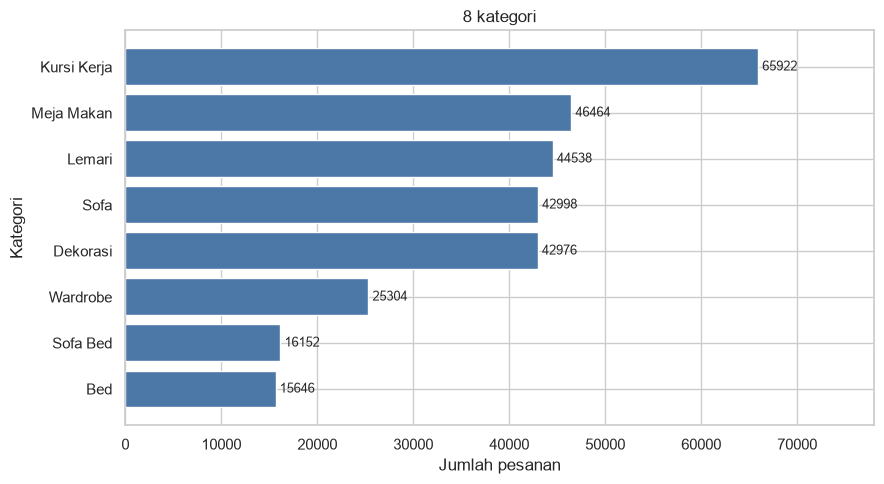

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

s1 = sesudah.sort_values()
b = ax.barh(s1.index, s1.values, color='#4C78A8')
ax.bar_label(b, padding=3, fontsize=9)
ax.set_title(f'{len(sesudah)} kategori')
ax.set_xlabel('Jumlah pesanan')
ax.set_ylabel('Kategori')
ax.set_xlim(0, 78000)

plt.tight_layout()
plt.show()

Bar chart horizontal dipakai karena yang dibandingkan adalah besaran antar kategori, dan nama
kategorinya panjang
*  Kursi Kerja dengan **65.922** — dan Sofa  **42.998**

### Menjawab Pertanyaan 3 — seberapa berantakan pencatatan kategori?

11 label dipakai untuk 8 jenis barang.
Empat label bermasalah, **Office Chair**, **Dining Table**, **lmri**, dan **sofabed**, hal ini berdampak pada
**395 SKU dan 78.502 pesanan (26,2% dari seluruh pesanan)**.

**standarisasinya:** satu prinsip yang diterapkan konsisten — digabung bila hanya berbeda
cara penulisan, dipisah bila berbeda cakupan atau fungsi barang

## 5.2 Menggabungkan tiga tabel

Kategori sudah bersih, sekarang ketiga tabel bisa digabung

In [23]:
# apakah ada pesanan yang produk atau tokonya tidak terdaftar?
print('sku_id tidak terdaftar :', (~orders['sku_id'].isin(products['sku_id'])).sum())
print('store_id tidak terdaftar :', (~orders['store_id'].isin(stores['store_id'])).sum())

# apakah kunci di tabel dimensi unik?
print('sku_id kembar :', products['sku_id'].duplicated().sum())
print('store_id kembar :', stores['store_id'].duplicated().sum())

sku_id tidak terdaftar : 0
store_id tidak terdaftar : 0
sku_id kembar : 0
store_id kembar : 0


Keempatnya nol. Penggabungan aman tidak akan ada baris kosong, dan tidak akan ada baris yang
berlipat ganda.

In [24]:
# gabungkan pesanan sebagai acuan
df = orders.merge(products_clean, on='sku_id', how='left')
df = df.merge(stores, on='store_id', how='left')

print('Baris sebelum digabung :', len(orders))
print('Baris sesudah digabung :', len(df))
print('Jumlah kolom :', df.shape[1])

Baris sebelum digabung : 300000
Baris sesudah digabung : 300000
Jumlah kolom : 14


**300.000 → 300.000.** Jumlah baris tidak berubah, seperti yang diharapkan

Sekarang saya akan perbaiki tipe tanggal dan membuat kolom turunan yang akan dipakai sepanjang
analisis

In [25]:
# ubah ketiga kolom tanggal dari teks menjadi tipe tanggal
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['installation_date'] = pd.to_datetime(df['installation_date'])

df[['order_date', 'delivery_date', 'installation_date']].dtypes

order_date           datetime64[us]
delivery_date        datetime64[us]
installation_date    datetime64[us]
dtype: object

In [26]:
# kolom turunan
df['lead_hari'] = (df['delivery_date'] - df['order_date']).dt.days      # pesan - barang tiba
df['gap_hari'] = (df['installation_date'] - df['delivery_date']).dt.days  # barang tiba -> dirakit
df['gagal'] = df['installation_status'].str.startswith('Failed')
df['bulan'] = df['order_date'].dt.to_period('M').astype(str)

In [27]:
# lokasi diambil dari nama toko dan pembelian digital diberi label 'Digital'
df['lokasi'] = df['store_name'].str.replace('DEC ', '', regex=False)
df['lokasi'] = df['lokasi'].str.replace(r' \d+$', '', regex=True)
df.loc[df['channel_type'] != 'Physical Store', 'lokasi'] = 'Digital'

df['lokasi'].value_counts()

lokasi
Alam Sutera      59962
Kelapa Gading    52340
Surabaya         37633
Bintaro          37583
Bekasi           30322
Kemang           29861
Medan            22329
Digital          15014
Bandung          14956
Name: count, dtype: int64

Empat kolom turunan siap: lead_hari, gap_hari, gagal, bulan, dan lokasi

**gap_hari** adalah **metrik utama** analisis ini,  selisih hari antara barang tiba dan tukang
datang. Delapan lokasi toko fisik plus satu kelompok Digital

## 5.3 Melihat sebaran kolom turunan

In [28]:
# sebaran lama pengiriman: pesan -> barang tiba
df['lead_hari'].value_counts().sort_index()

lead_hari
2    49985
3    49422
4    50295
5    50423
6    50057
7    49818
Name: count, dtype: int64

In [29]:
# sebaran selisih perakitan: barang tiba -> tukang datang
df['gap_hari'].value_counts().sort_index()

gap_hari
-3.0     1478
-2.0     1516
-1.0     1576
 0.0    30907
 1.0    30749
 2.0    30914
 3.0    30817
 4.0    31272
 5.0    31046
Name: count, dtype: int64

Dua sebaran ini memunculkan **tiga hal sekaligus**.

**Pertama — lead_hari rata sempurna.** Enam nilai (2–7 hari), masing-masing sekitar 50.000
pesanan. Tidak ada hari yang lebih sering dipakai daripada yang lain. Untuk sebuah jadwal
pengiriman

**Kedua — gap_hari hanya punya 190.275 nilai**, bukan 300.000. Berarti ada **109.725 baris
kosong**. Ini cocok dengan nilai kosong installation_date yang sudah terlihat di 4.3, dan
sebabnya harus dipastikan dulu

**Ketiga — gap_hari punya nilai negatif** (−1, −2, −3). Artinya tukang tercatat merakit
**sebelum barangnya tiba**

## 5.4 installer_id dan installation_date kosong

Dua kolom ini kosong pada **109.725 baris (36,58%)**, dan jumlahnya sama persis. Sebelum
memutuskan apa pun, kita harus tahu **kenapa** kosong. Ada dua kemungkinan, dan penanganannya
berlawanan:

* **Data hilang** — nilainya seharusnya ada tapi tidak tercatat → perlu diisi atau dibuang.
* **Data tidak berlaku** — nilainya memang tidak pernah ada → tidak boleh diisi, tidak boleh
  dibuang.

Mari kita buktikan yang mana.

In [30]:
# apakah kedua kolom selalu kosong bersamaan?
sama = (df['installer_id'].isna() == df['installation_date'].isna()).all()
print('Selalu kosong bersamaan:', sama)

Selalu kosong bersamaan: True


In [31]:
# status perakitan pada baris yang installer_id-nya KOSONG
df[df['installer_id'].isna()]['installation_status'].value_counts()

installation_status
No Assembly Required    76030
No Assembly Service     33695
Name: count, dtype: int64

In [32]:
# status perakitan pada baris yang installer_id-nya TERISI
df[df['installer_id'].notna()]['installation_status'].value_counts()

installation_status
Success                   152357
Failed - Missing Parts     22639
Failed - Damaged Panel     15279
Name: count, dtype: int64

Terbukti. Keduanya **selalu kosong bersamaan**, dan pemisahannya sempurna tanpa satu pun
pengecualian:

* Yang **kosong**: seluruhnya No Assembly Required (76.030) + No Assembly Service (33.695)
* Yang **terisi**: seluruhnya Success, Failed - Missing Parts, Failed - Damaged Panel

Artinya ini **data yang tidak berlaku, bukan data yang hilang**. Pesanan yang barangnya tidak
perlu dirakit, atau pelanggannya tidak mengambil jasa rakit, memang tidak pernah punya tukang dan
tanggal perakitan.

**Keputusan saya** dibiarkan kosong Kalau di-dropna(), 109.725 pesanan yang sah ikut terbuang —
dan yang terbuang justru seluruh pesanan tanpa perakitan, sehingga setiap perhitungan porsi
setelah itu menjadi bias

Konsekuensi pada perhitungan nanti dan ini menentukan benar-salahnya angka

| Perhitungan | Pembagi | Alasan |
|---|---|---|
| Tingkat kegagalan | **190.275** | hanya pesanan yang benar-benar dirakit yang bisa gagal |
| Selisih hari | **190.275** | hanya pesanan yang dirakit yang punya selisih |
| Porsi kategori / saluran | **300.000** | seluruh pesanan punya kategori dan saluran |


## 5.5 Tanggal perakitan mendahului pengiriman

Ada 4.570 pesanan yang tanggalnya mustahil. Sebelum memutuskan cara menanganinya, kita perlu tahu
**dari mana asalnya**. Tiga pertanyaan:

* Status perakitannya apa saja?
* Berapa jauh selisihnya?
* Apakah menumpuk di kategori, lokasi, bulan, atau tukang tertentu?

Jawaban ketiganya menentukan bentuk perbaikannya: kalau menumpuk di satu tempat, perbaikannya
lokal; kalau merata, perbaikannya harus di sistem.

In [33]:
# baris dengan tanggal terbalik
terbalik = df[df['gap_hari'] < 0]
print('Jumlah pesanan bertanggal terbalik:', len(terbalik))

# status perakitannya
terbalik['installation_status'].value_counts()

Jumlah pesanan bertanggal terbalik: 4570


installation_status
Success    4570
Name: count, dtype: int64

In [34]:
# seberapa jauh selisihnya?
terbalik['gap_hari'].value_counts().sort_index()

gap_hari
-3.0    1478
-2.0    1516
-1.0    1576
Name: count, dtype: int64

Dua hal langsung menonjol.

**Pertama, seluruhnya berstatus Success 4.570 dari 4.570, tanpa satu pun pengecualian.**
Tukang menyatakan perakitan berhasil atas barang yang menurut catatan belum tiba

**Kedua, selisihnya hanya 1 sampai 3 hari** (1.576 + 1.516 + 1.478)

In [35]:
# hanya pesanan yang dirakit yang punya kesempatan mengalami kesalahan ini
dirakit = df[df['installation_status'].isin(
    ['Success', 'Failed - Missing Parts', 'Failed - Damaged Panel'])].copy()
dirakit['terbalik'] = dirakit['gap_hari'] < 0

print('Dari seluruh pesanan   : %.2f%%' % (len(terbalik) / len(df) * 100))
print('Dari pesanan yang dirakit: %.2f%%' % (len(terbalik) / len(dirakit) * 100))

Dari seluruh pesanan   : 1.52%
Dari pesanan yang dirakit: 2.40%


In [36]:
# uji chi-square: apakah tanggal terbalik menumpuk di segmen tertentu?
for kolom in ['category', 'lokasi', 'channel_type', 'bulan', 'installer_id']:
    tabel = pd.crosstab(dirakit[kolom], dirakit['terbalik'])
    p = chi2_contingency(tabel)[1]
    arti = 'MENUMPUK' if p < 0.05 else 'tersebar merata'
    print(f'{kolom:15s} p-value = {p:.4f}  ->  {arti}')

category        p-value = 0.3397  ->  tersebar merata
lokasi          p-value = 0.1942  ->  tersebar merata
channel_type    p-value = 0.5126  ->  tersebar merata
bulan           p-value = 0.8268  ->  tersebar merata
installer_id    p-value = 0.6823  ->  tersebar merata


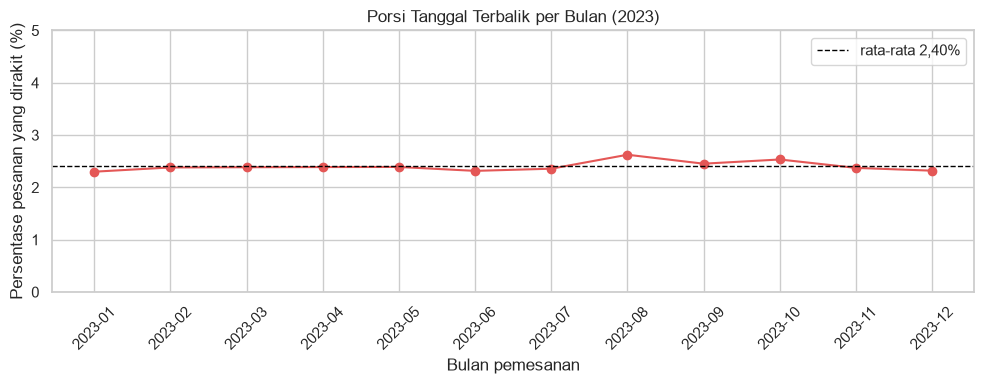

In [37]:
# porsi tanggal terbalik per bulan
per_bulan = dirakit.groupby('bulan')['terbalik'].mean() * 100

plt.figure(figsize=(10, 4))
plt.plot(per_bulan.index, per_bulan.values, marker='o', color='#E45756')
plt.axhline(2.40, color='black', linestyle='--', linewidth=1, label='rata-rata 2,40%')
plt.ylim(0, 5)
plt.title('Porsi Tanggal Terbalik per Bulan (2023)')
plt.xlabel('Bulan pemesanan')
plt.ylabel('Persentase pesanan yang dirakit (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Line chart dipakai karena datanya berurutan waktu, dan yang ditampilkan **porsi** bukan jumlah 
bulan dengan pesanan lebih banyak otomatis punya lebih banyak kesalahan tanpa berarti lebih
bermasalah

Kelima uji menghasilkan p-value **jauh di atas 0,05**, termasuk uji terhadap **999 tukang
sekaligus** (p = 0,6823). Garis bulanannya mendatar di kisaran 2,3%–2,6%

In [38]:
# petunjuk terakhir: apakah jam pada kedua tanggal sama?
jam_sama = (df['delivery_date'].dt.time == df['installation_date'].dt.time).sum()
print('Jam delivery = jam installation :', jam_sama, 'dari', df['installation_date'].notna().sum())

Jam delivery = jam installation : 190275 dari 190275


**Jamnya identik pada seluruh 190.275 baris.** Truk yang datang pukul 17:00 dan tukang yang datang
beberapa hari kemudian mustahil tiba pada menit yang sama persis, ratusan ribu kali berturut-turut.

Ini menutup rangkaian buktinya: **tanggal perakitan dihitung oleh sistem dari tanggal pengiriman,
bukan dicatat dari lapangan.**

### **Menjawab Pertanyaan 4 — berapa pesanan yang tanggalnya mustahil?**

**4.570 pesanan** — **1,52%** dari 300.000, atau **2,40%** dari 190.275 pesanan yang dirakit.
Selisihnya 1–3 hari sebelum barang tiba, dan **seluruhnya berstatus Success**

**kesalahan ini asalnya bukan manusia, melainkan sistem.** data tersebar merata di seluruh kategori, lokasi,
saluran, bulan, dan 999 tukang (p antara 0,19 dan 0,83), seragam 100% pada status, dan jam
perakitannya selalu identik dengan jam pengiriman

**Karena itu perbaikannya berupa validasi di sistem**, bukan pembinaan cabang atau tukang


## 5.6 biaya perakitan yang tidak wajar

Dari 4.3 kita tahu ada nilai −150.000 dan 99.900.000
saya melakukan urutan pemeriksaan berikut:

1. Pilah nilainya — berapa yang nol, negatif, dan ekstrem?
2. Nilai nol itu sah atau salah?
3. Apakah nilai yang rusak **bisa diperkirakan** dari kolom lain?
4. Kalau tidak bisa, barulah ditandai.

Langkah 3 yang menentukan kalau ada korelasi, nilainya masih bisa ditaksir dan tidak perlu
dikorbankan.

In [39]:
# pilah nilai assembly_fee
fee = df['assembly_fee']
print('bernilai nol :', (fee == 0).sum())
print('bernilai negatif :', (fee < 0).sum())
print('di atas 1 juta :', (fee > 1_000_000).sum())
print('di atas 10 juta :', (fee > 10_000_000).sum())

bernilai nol : 109725
bernilai negatif : 960
di atas 1 juta : 933
di atas 10 juta : 933


In [40]:
# status perakitan pada baris yang biayanya NOL
df[df['assembly_fee'] == 0]['installation_status'].value_counts()

installation_status
No Assembly Required    76030
No Assembly Service     33695
Name: count, dtype: int64

In [41]:
# berapa nilai berbeda yang ada di kolom ini?
print('Jumlah nilai unik:', fee.nunique())
print()
print('Nilai negatif :', sorted(fee[fee < 0].unique()))
print('Nilai ekstrem :', sorted(fee[fee > 1_000_000].unique()))
print('Nilai antara 250.000 dan 99.900.000 :', ((fee > 250_000) & (fee < 99_900_000)).sum())

Jumlah nilai unik: 24

Nilai negatif : [np.int64(-150000)]
Nilai ekstrem : [np.int64(99900000)]
Nilai antara 250.000 dan 99.900.000 : 0


**Ini temuannya.** Seluruh 1.893 baris anomali hanya berisi **dua nilai berbeda**:

* 960 baris bernilai persis **−150.000**
* 933 baris bernilai persis **99.900.000**

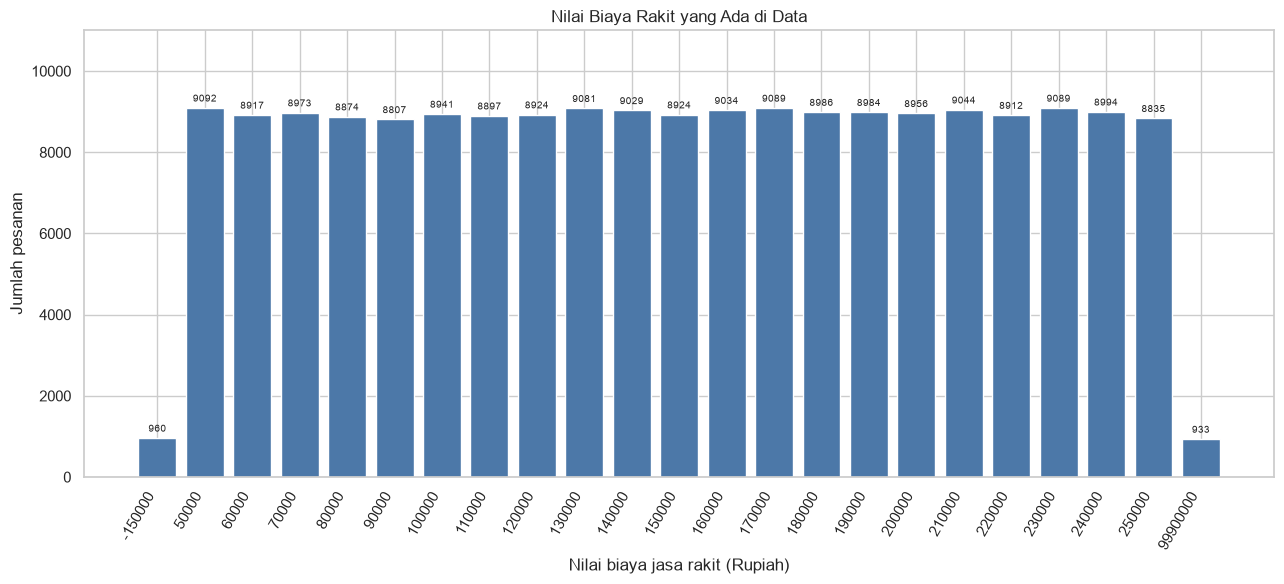

In [42]:
nilai_biaya = df['assembly_fee'].value_counts().sort_index()
nilai_biaya = nilai_biaya[nilai_biaya.index != 0]

plt.figure(figsize=(13, 6))
bar = plt.bar(nilai_biaya.index.astype(str), nilai_biaya.values, color='#4C78A8')
plt.bar_label(bar, padding=3, fontsize=7.5)

plt.title('Nilai Biaya Rakit yang Ada di Data')
plt.xlabel('Nilai biaya jasa rakit (Rupiah)')
plt.ylabel('Jumlah pesanan')
plt.xticks(rotation=60, ha='right')
plt.ylim(0, 11000)
plt.tight_layout()
plt.show()

**Terlihat pada bar chart** kolom ini hanya berisi **24 nilai berbeda**, jadi isinya
daftar tarif, bukan angka bersambung. Nilai 0 tidak saya tampilkan karena jumlahnya
109.725 dan sudah terbukti sah di sel sebelumnya.

21 batang di tengah adalah tarif resmi **50.000 sampai 250.000** kelipatan 10.000,
masing-masing sekitar **9.000 pesanan**. Dua batang di ujung berada di luar daftar itu:
**−150.000 sebanyak 960 kali** dan **99.900.000 sebanyak 933 kali**.

Kalau ini salah ketik kasir, nilainya pasti bermacam-macam. Yang ada justru hanya dua
nilai yang berulang ratusan kali, jadi menurut saya ini **kesalahan sistem**, bukan
kesalahan orang.

In [43]:
# apakah nilai biaya bisa diperkirakan dari kolom lain? cek korelasinya
angka = df[['assembly_fee', 'lead_hari', 'gap_hari']].dropna()

print('Korelasi Pearson (hubungan lurus):')
display(angka.corr().round(3))

print('Korelasi Spearman (tahan terhadap outlier):')
display(angka.corr(method='spearman').round(3))

Korelasi Pearson (hubungan lurus):


,assembly_fee,lead_hari,gap_hari
assembly_fee,1.000,0.005,-0.002
lead_hari,0.005,1.000,-0.000
gap_hari,-0.002,-0.000,1.000


Korelasi Spearman (tahan terhadap outlier):


,assembly_fee,lead_hari,gap_hari
assembly_fee,1.000,0.001,-0.002
lead_hari,0.001,1.000,-0.000
gap_hari,-0.002,-0.000,1.000


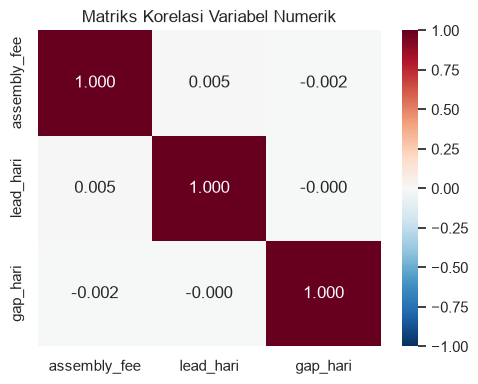

In [44]:
plt.figure(figsize=(5, 4))
sns.heatmap(angka.corr(), annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

Heatmap dipakai supaya seluruh pasangan korelasi terbaca sekaligus dalam satu tampilan, dengan
warna sebagai penanda arah dan kekuatan.

Seluruh korelasinya nol,  Angka terbesar hanya **0,005** — dua puluh kali lebih kecil daripada
0,1 yang biasa dianggap batas "ada hubungan". Pearson dan Spearman sepakat, jadi ini bukan efek
samping outlier.

Artinya nilai biaya yang rusak tidak bisa diperkirakan dari kolom mana pun

In [45]:
# apakah biaya anomali berhubungan dengan kegagalan perakitan?
berhasil = dirakit[~dirakit['gagal']]['assembly_fee']
gagal = dirakit[dirakit['gagal']]['assembly_fee']

p = mannwhitneyu(berhasil, gagal)[1]
print('median biaya, perakitan berhasil : %.0f' % berhasil.median())
print('median biaya, perakitan gagal : %.0f' % gagal.median())
print('Mann-Whitney p-value : %.4f' % p)

median biaya, perakitan berhasil : 150000
median biaya, perakitan gagal : 150000
Mann-Whitney p-value : 0.9332


Mann-Whitney dipakai, bukan t-test, karena sebaran biayanya tidak normal.

**p = 0,9332** — tidak ada beda nyata. Perakitan yang gagal tidak lebih mahal maupun lebih murah.
Berarti nilai anomali itu **tidak membawa informasi apa pun tentang kegagalan** yang akan hilang
kalau dikosongkan.

Semua jalan untuk menyelamatkan nilainya sudah tertutup

In [46]:
# df hasil tetap utuh sebagai pembanding
df_clean = df.copy()

# 1. tandai tanggal yang mustahil, lalu kosongkan selisih harinya
df_clean['tanggal_valid'] = df_clean['gap_hari'] >= 0
df_clean.loc[df_clean['gap_hari'] < 0, 'gap_hari'] = np.nan

In [47]:
# 2. tandai biaya yang tidak sah, lalu kosongkan nilainya
tidak_sah = (df_clean['assembly_fee'] < 0) | (df_clean['assembly_fee'] > 1_000_000)
df_clean['biaya_valid'] = ~tidak_sah
df_clean.loc[tidak_sah, 'assembly_fee'] = np.nan

print('Baris dihapus :', len(df) - len(df_clean))
print('Tanggal ditandai tidak sah :', (~df_clean['tanggal_valid']).sum())
print('Biaya dikosongkan :', (~df_clean['biaya_valid']).sum())

Baris dihapus : 0
Tanggal ditandai tidak sah : 114295
Biaya dikosongkan : 1893


**Nol baris dihapus.** Kesalahan terjadi pada satu kolom, bukan pada seluruh baris — pesanan
dengan biaya rusak tetap punya nomor pesanan, produk, toko, tukang, dan status perakitan yang sah.

Ada alasan yang lebih tajam lagi untuk tidak menghapus baris bertanggal terbalik: **seluruh 4.570
baris itu berstatus Success**. Menghapusnya berarti membuang 4.570 keberhasilan tanpa membuang
satu pun kegagalan — sehingga tingkat kegagalan **naik secara semu**. Kita buktikan di 5.6.

### Menjawab Pertanyaan 5 berapa nilai biaya yang tidak wajar, dan dari mana asalnya?

- **1.893 nilai** — 960 negatif dan 933 ekstrem

- **tapi asalnya bukan kesalahan kasir** tetapi Seluruh 1.893 baris itu hanya berisi **dua nilai
berbeda**: −150.000 (960 kali) dan 99.900.000 (933 kali), tanpa variasi sama sekali

- **Nilainya juga tidak bisa diselamatkan** — korelasi dengan seluruh variabel lain hanya 0,005,
jadi tidak ada dasar untuk memperkirakan nilai yang benar

## 5.7 Data yang sudah bersih

Pembersihan selesai. Mari kita bandingkan sebelum dan sesudah, untuk memastikan **yang berubah
hanya yang seharusnya berubah**.

In [48]:
dipasang_kolom = ['Success', 'Failed - Missing Parts', 'Failed - Damaged Panel']

banding = pd.DataFrame({
    'Sebelum': [len(df),
                df['assembly_fee'].min(),
                df['assembly_fee'].max(),
                df['gap_hari'].min(),
                round(df['gagal'].sum() / df['installation_status'].isin(dipasang_kolom).sum() * 100, 2)],
    'Sesudah': [len(df_clean),
                df_clean['assembly_fee'].min(),
                df_clean['assembly_fee'].max(),
                df_clean['gap_hari'].min(),
                round(df_clean['gagal'].sum() / df_clean['installation_status'].isin(dipasang_kolom).sum() * 100, 2)]
}, index=['Jumlah baris', 'Biaya terkecil', 'Biaya terbesar', 'Selisih hari terkecil',
          'Tingkat kegagalan (%)'])
banding

,Sebelum,Sesudah
Jumlah baris,300000.00,300000.00
Biaya terkecil,-150000.00,0.00
Biaya terbesar,99900000.00,250000.00
Selisih hari terkecil,-3.00,0.00
Tingkat kegagalan (%),19.93,19.93


In [49]:
# Melakukan cek baris yang tanggalnya terbalik apabila di hapus
gagal_jml = df['gagal'].sum()
dirakit_jml = df['installation_status'].isin(dipasang_kolom).sum()

print('Tingkat kegagalan sekarang : %.2f%%' % (gagal_jml / dirakit_jml * 100))
print('Kalau 4.570 baris dihapus : %.2f%%' % (gagal_jml / (dirakit_jml - 4570) * 100))

Tingkat kegagalan sekarang : 19.93%
Kalau 4.570 baris dihapus : 20.42%


+ **Terlihat pada tabel** yang berubah cuma kolom biaya dan selisih hari. Biaya terkecil
dari **−150.000 jadi 0**, terbesar dari **99.900.000 jadi 250.000**, dan selisih hari
terkecil dari **−3 jadi 0**.

+ Perhitungan kedua saya pakai untuk menguji kalau 4.570 baris tanggal terbalik saya hapus.
Hasilnya tingkat kegagalan naik jadi **20,42%**, padahal tidak ada satu perakitan pun yang
berubah jadi gagal. Naiknya cuma karena pembaginya berkurang. Itu sebabnya saya pilih
**menandai, bukan menghapus**.

| Anomali | Jumlah | Yang saya lakukan |
|---|---|---|
| Kategori tidak standar | 4 label, 78.502 pesanan | disatukan jadi 8 kategori |
| installer_id & installation_date kosong | 109.725 | dibiarkan, datanya memang tidak berlaku |
| Tanggal terbalik | 4.570 | ditandai, gap_hari dikosongkan |
| Biaya negatif dan ekstrem | 1.893 | ditandai, nilainya dikosongkan |
| Kolom tanggal masih teks | 3 kolom | diubah jadi tipe tanggal |

**Tidak ada satu baris pun yang saya hapus dari 300.000 pesanan.** Yang saya kosongkan
cuma nilai di kolom yang bermasalah, jadi kolom lain di baris itu masih bisa dipakai

### Menyimpan data bersih

Data bersihnya saya simpan jadi satu berkas supaya bisa dipakai ulang di Tableau tanpa
menjalankan notebook ini lagi.

Ada tiga kolom yang saya tambahkan khusus untuk itu. tunggu_hari supaya total waktu tunggu tidak
perlu dihitung ulang. penuhi_target supaya target 24 jam bisa langsung jadi filter. Dan
hasil_perakitan yang berisi tiga nilai, yaitu Berhasil, Gagal, dan Tidak dirakit.

Kolom ketiga itu yang paling penting. Kolom gagal bernilai False untuk 109.725 pesanan yang
memang tidak pernah dirakit, jadi kalau kolom itu yang dipakai, pembaginya jadi 300.000 dan tingkat
kegagalannya terbaca 12,64%. Dengan hasil_perakitan, nilai Tidak dirakit tinggal dibuang dari
filter dan pembaginya otomatis kembali ke 190.275.


In [50]:
# simpan data bersih untuk divisualisasikan di Tableau
ekspor = df_clean.copy()

# waktu tunggu ikut disimpan supaya tidak perlu dihitung ulang di Tableau
ekspor['tunggu_hari'] = ekspor['lead_hari'] + ekspor['gap_hari']

# hasil perakitan dibuat tiga nilai supaya pembaginya tidak keliru di Tableau
ekspor['hasil_perakitan'] = 'Tidak dirakit'
ekspor.loc[ekspor['installation_status'] == 'Success', 'hasil_perakitan'] = 'Berhasil'
ekspor.loc[ekspor['gagal'], 'hasil_perakitan'] = 'Gagal'

# pemenuhan target 24 jam, dikosongkan kalau tanggalnya tidak sah
ekspor['penuhi_target'] = 'Melewati'
ekspor.loc[ekspor['gap_hari'] <= 1, 'penuhi_target'] = 'Memenuhi'
ekspor.loc[ekspor['gap_hari'].isna(), 'penuhi_target'] = None

kolom = ['order_id', 'order_date', 'delivery_date', 'installation_date',
         'store_id', 'store_name', 'channel_type', 'lokasi',
         'sku_id', 'product_name', 'category', 'is_assembly_required',
         'installer_id', 'installation_status', 'hasil_perakitan',
         'assembly_fee', 'lead_hari', 'gap_hari', 'tunggu_hari',
         'penuhi_target', 'bulan', 'tanggal_valid', 'biaya_valid']

ekspor[kolom].to_csv('../output/dekoruma_clean.csv', index=False)

print('Baris disimpan :', len(ekspor))
print('Kolom disimpan :', len(kolom))


Baris disimpan : 300000
Kolom disimpan : 23


## 5.8 Berapa lama pelanggan sebenarnya menunggu?

Data sudah bersih. sekarang saya baru perhitungan waktu bisa dipercaya dan hal pertama yang layak
dihitung adalah **yang benar-benar dirasakan pelanggan**: berapa lama sejak membayar sampai
barangnya berdiri terpasang di rumah

In [51]:
# hanya pesanan yang dirakit DAN tanggalnya sah
sah = df_clean[df_clean['gap_hari'].notna()].copy()

# total waktu tunggu pelanggan = pesan -> barang tiba -> selesai dirakit
sah['tunggu_hari'] = sah['lead_hari'] + sah['gap_hari']

print('Pesanan yang dipakai :', len(sah))
print('Rata-rata waktu tunggu : %.2f hari' % sah['tunggu_hari'].mean())
print('Nilai tengah (median) : %.0f hari' % sah['tunggu_hari'].median())
print('Rentang : %.0f - %.0f hari' % (sah['tunggu_hari'].min(), sah['tunggu_hari'].max()))
print()
print('Menunggu >= 10 hari : %d (%.1f%%)' % ((sah['tunggu_hari'] >= 10).sum(),(sah['tunggu_hari'] >= 10).mean() * 100))
print('Selesai dalam <= 4 hari : %d (%.1f%%)' % ((sah['tunggu_hari'] <= 4).sum(),(sah['tunggu_hari'] <= 4).mean() * 100))

Pesanan yang dipakai : 185705
Rata-rata waktu tunggu : 7.01 hari
Nilai tengah (median) : 7 hari
Rentang : 2 - 12 hari

Menunggu >= 10 hari : 31047 (16.7%)
Selesai dalam <= 4 hari : 30634 (16.5%)


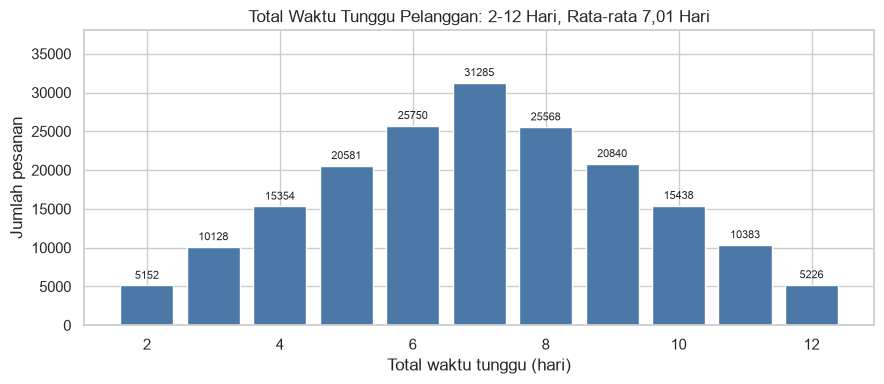

In [52]:
# sebaran total waktu tunggu pelanggan
sebaran = sah['tunggu_hari'].value_counts().sort_index()

plt.figure(figsize=(9, 4))
bar = plt.bar(sebaran.index.astype(int), sebaran.values, color='#4C78A8')
plt.bar_label(bar, padding=3, fontsize=8)

plt.title('Total Waktu Tunggu Pelanggan: 2-12 Hari, Rata-rata 7,01 Hari')
plt.xlabel('Total waktu tunggu (hari)')
plt.ylabel('Jumlah pesanan')
plt.ylim(0, 38000)
plt.tight_layout()
plt.show()

**Terlihat pada bar chart** ini yang benar-benar dirasakan pelanggan dari bayar sampai
barang terpasang. Saya pakai bar chart karena lama tunggunya cuma 11 macam angka, jadi
tiap hari bisa jadi satu batang. Dihitung dari **185.705 pesanan** yang tanggalnya sah.

Paling cepat **2 hari**, paling lama **12 hari**, rata-rata **7 hari**. Batang tertinggi
di hari ke-7 dengan **31.285 pesanan**, lalu melandai ke kiri dan ke kanan.

Yang jadi perhatian saya batang di sebelah kanan. Ada 15.438 pesanan yang menunggu 10 hari,
10.383 yang 11 hari, dan 5.226 yang 12 hari. Totalnya **31.047 pesanan atau 16,7%** menunggu
**10 hari ke atas**.

In [53]:
# kalau dua tahap acak dijumlahkan, hasilnya SELALU berbentuk segitiga.
# bobot teoretisnya: 1,2,3,4,5,6,5,4,3,2,1 dari total 36 kemungkinan
bobot = np.array([1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1]) / 36
harapan = (bobot * len(sah)).round(0)

banding = pd.DataFrame({'hari': sebaran.index.astype(int),
                        'teramati': sebaran.values,
                        'kalau_dua_tahap_acak': harapan.astype(int)})
banding['meleset_%'] = ((banding['teramati'] / banding['kalau_dua_tahap_acak'] - 1) * 100).round(2)
display(banding)

print('Rata-rata meleset : %.2f%%' % banding['meleset_%'].abs().mean())
print('Korelasi tahap 1 vs tahap 2 : %.4f' % sah['lead_hari'].corr(sah['gap_hari']))

,hari,teramati,kalau_dua_tahap_acak,meleset_%
0,2,5152,5158,-0.12
1,3,10128,10317,-1.83
2,4,15354,15475,-0.78
3,5,20581,20634,-0.26
4,6,25750,25792,-0.16
5,7,31285,30951,1.08
6,8,25568,25792,-0.87
7,9,20840,20634,1.00
8,10,15438,15475,-0.24
9,11,10383,10317,0.64


Rata-rata meleset : 0.75%
Korelasi tahap 1 vs tahap 2 : -0.0007


**Angka nyatanya meleset rata-rata hanya 0,75%** dari pola yang dihasilkan dua tahap acak, dan
korelasi antar kedua tahap **−0,0007** — praktis nol.

**Ini bukti kuantitatif, bukan dugaan: kedua tahap dijadwalkan secara acak dan sama sekali tidak saling melihat**

Akibatnya pada pelanggan bisa dibaca langsung dari panel kanan. **31.047 pesanan (16,7%)
menunggu 10 hari atau lebih** bukan karena kasusnya sulit, melainkan karena kebetulan mendapat
dua jadwal panjang berturut-turut

In [54]:
# berapa yang memenuhi target 24 jam?
target = (sah['gap_hari'] <= 1).sum()
hari_sama = (sah['gap_hari'] == 0).sum()

print('Dirakit di hari yang sama : %d (%.1f%%)' % (hari_sama, hari_sama / len(sah) * 100))
print('Memenuhi target <= 1 hari : %d (%.1f%%)' % (target, target / len(sah) * 100))
print('MELEWATI target > 1 hari  : %d (%.1f%%)' % (len(sah) - target, (len(sah) - target) / len(sah) * 100))

Dirakit di hari yang sama : 30907 (16.6%)
Memenuhi target <= 1 hari : 61656 (33.2%)
MELEWATI target > 1 hari  : 124049 (66.8%)


Sekarang pertanyaan lanjutannya apakah ada lokasi atau bulan yang lebih buruk

In [55]:
# pemenuhan target per lokasi
per_lokasi = sah.groupby('lokasi')['gap_hari'].agg(pesanan='size', rata_rata='mean').round(2)
per_lokasi['penuhi_target_%'] = (sah[sah['gap_hari'] <= 1].groupby('lokasi').size()
                                 / sah.groupby('lokasi').size() * 100).round(2)
per_lokasi.sort_values('penuhi_target_%')

,pesanan,rata_rata,penuhi_target_%
lokasi,,,
Bandung,9328,2.52,32.76
Kemang,18496,2.51,32.86
Bintaro,23277,2.52,33.00
Surabaya,23219,2.49,33.25
Medan,13758,2.51,33.29
Kelapa Gading,32500,2.51,33.29
Alam Sutera,37166,2.50,33.30
Bekasi,18703,2.51,33.38
Digital,9258,2.50,33.51


In [56]:
# uji beda: apakah selisih hari berbeda antar lokasi dan antar bulan?
kelompok_lokasi = [g['gap_hari'].values for _, g in sah.groupby('lokasi')]
kelompok_bulan = [g['gap_hari'].values for _, g in sah.groupby('bulan')]

print('Kruskal-Wallis antar lokasi : p = %.4f' % kruskal(*kelompok_lokasi)[1])
print('Kruskal-Wallis antar bulan : p = %.4f' % kruskal(*kelompok_bulan)[1])

Kruskal-Wallis antar lokasi : p = 0.9490
Kruskal-Wallis antar bulan : p = 0.2060


Kruskal-Wallis dipakai karena membandingkan lebih dari dua kelompok dan tidak mensyaratkan sebaran
normal.

**Keduanya jauh di atas 0,05** (lokasi 0,9490; bulan 0,2060). Selisih pemenuhan target antara
lokasi terbaik (Digital 33,51%) dan terburuk (Bandung 32,76%) hanya **0,75 poin persen**.

Semua penjelasan lokal tertutup bukan soal wilayah, bukan soal musim, bukan soal saluran. Kalau
seluruh tempat dan seluruh bulan menghasilkan angka yang sama, penyebabnya ada pada **proses yang
dipakai semuanya** — yaitu cara jadwal disusun.

Kabar baiknya: satu perubahan aturan akan berdampak ke seluruh operasi sekaligus.

 ### pertanyaan 1. berapa rata-rata selisih hari?

 **Selisih barang tiba ke perakitan: rata-rata 2,51 hari** (nilai tengah 3, rentang 0–5),
 dihitung dari 185.705 pesanan bertanggal sah. Hanya **33,2%** memenuhi target 24 jam.

 **Tetapi angka yang benar-benar berarti bagi pelanggan adalah totalnya: 7,01 hari** sejak
 membayar sampai barang terpasang, dengan rentang **2 sampai 12 hari**. **31.047 pesanan
 (16,7%) menunggu 10 hari atau lebih.**

 **Penyebabnya bukan keterlambatan, melainkan ketiadaan koordinasi.** Kedua tahap terbukti
 dijadwalkan acak dan saling bebas — sebaran totalnya meleset hanya **0,75%** dari pola dua
 tahap acak, dengan korelasi antar tahap **−0,0007**.

 Keadaan ini seragam di seluruh lokasi (p = 0,9490) dan seluruh bulan (p = 0,2060), jadi tidak
 ada cabang atau periode yang bisa ditunjuk.

 **Yang membuatnya bisa diperbaiki:** perakitan di hari yang sama **sudah terjadi 30.907 kali**
 sepanjang tahun tanpa satu pun aturan yang mendorongnya. Kapasitasnya sudah ada — yang belum
 ada hanya aturan yang menyatukan kedua jadwal.

# 6. Data Analysis

Tersisa hanya satu pertanyaan yang membutuhkan seluruh tabel dalam keadaan bersih: **kenapa
satu dari lima perakitan gagal?**

## 6.1 Kategori furnitur apa yang paling sering gagal dirakit?

Dua hal yang perlu diputuskan sebelum menghitung:

* **Pembaginya apa?** Kegagalan hanya mungkin pada pesanan yang benar-benar dirakit — 190.275,
  bukan 300.000.
* **Yang dibandingkan jumlah atau persentase?** Harus persentase. Kategori dengan pesanan
  terbanyak otomatis punya kegagalan terbanyak, tanpa berarti lebih bermasalah.

In [57]:
# tingkat kegagalan keseluruhan, dengan dua pembagi berbeda
rakit = df_clean[df_clean['installation_status'].isin(
    ['Success', 'Failed - Missing Parts', 'Failed - Damaged Panel'])]

print('Pesanan yang dirakit :', len(rakit))
print('Perakitan yang gagal :', rakit['gagal'].sum())
print('Tingkat kegagalan (pembagi 190.275) : %.2f%%' % (rakit['gagal'].mean() * 100))
print('Tingkat kegagalan (pembagi 300.000) : %.2f%%' % (rakit['gagal'].sum() / len(df_clean) * 100))

Pesanan yang dirakit : 190275
Perakitan yang gagal : 37918
Tingkat kegagalan (pembagi 190.275) : 19.93%
Tingkat kegagalan (pembagi 300.000) : 12.64%


Selisihnya besar: **19,93% lawan 12,64%**. Angka kedua menyusut lebih dari sepertiga hanya karena
pembaginya salah.

Bagi Head of Operations, perbedaannya menentukan: 12,6% terbaca *"satu dari delapan bermasalah"*
dan masih bisa ditunda; 19,9% terbaca *"satu dari lima"* dan sulit diabaikan.

Sekarang per kategori.

In [58]:
# tingkat kegagalan per kategori
per_kat = rakit.groupby('category')['gagal'].agg(dirakit='size', gagal='sum')
per_kat['tingkat_%'] = (per_kat['gagal'] / per_kat['dirakit'] * 100).round(2)
per_kat.sort_values('tingkat_%', ascending=False)

,dirakit,gagal,tingkat_%
category,,,
Sofa Bed,6696,1366,20.40
Sofa,15490,3121,20.15
Meja Makan,39499,7930,20.08
Bed,13374,2682,20.05
Wardrobe,21554,4316,20.02
Kursi Kerja,55806,11082,19.86
Lemari,37856,7421,19.60


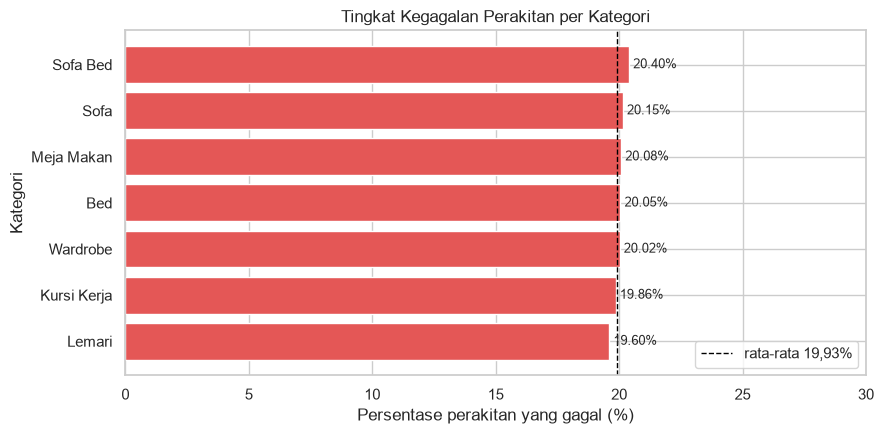

In [59]:
urut = per_kat.sort_values('tingkat_%')

plt.figure(figsize=(9, 4.5))
bar = plt.barh(urut.index, urut['tingkat_%'], color='#E45756')
plt.bar_label(bar, fmt='%.2f%%', padding=3, fontsize=9)
plt.axvline(19.93, color='black', linestyle='--', linewidth=1, label='rata-rata 19,93%')
plt.title('Tingkat Kegagalan Perakitan per Kategori')
plt.xlabel('Persentase perakitan yang gagal (%)')
plt.ylabel('Kategori')
plt.xlim(0, 30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [60]:
# apakah perbedaan antar kategori itu nyata, atau hanya kebetulan?
p_kategori = chi2_contingency(pd.crosstab(rakit['category'], rakit['gagal']))[1]
print('Chi-square kegagalan antar kategori : p = %.4f' % p_kategori)
print('Selisih tertinggi - terendah : %.2f poin persen'
      % (per_kat['tingkat_%'].max() - per_kat['tingkat_%'].min()))

Chi-square kegagalan antar kategori : p = 0.5588
Selisih tertinggi - terendah : 0.80 poin persen


- Garis putus-putus rata-rata sengaja dipasang supaya besar-kecilnya penyimpangan langsung terlihat
dan yang terlihat adalah **hampir tidak ada penyimpangan**.

- Ketujuh kategori berada di rentang **19,60%–20,40%**, selisihnya cuma **0,80 poin persen**, dan
chi-square memberi **p = 0,5588**. Perbedaan sekecil itu berada dalam batas kebetulan

- **Jadi jawabannya: tidak ada kategori yang paling sering gagal** tapi Secara harfiah Sofa Bed
teratas, tapi menyebutnya "kategori terburuk" berarti menyalahkan kategori yang sama saja dengan
yang lain terlebih ia kelompok terkecil (6.696 perakitan) yang paling mudah bergeser

In [61]:
# apakah kegagalan menumpuk di segmen tertentu?
for kolom in ['category', 'lokasi', 'store_name', 'channel_type', 'bulan', 'installer_id']:
    p = chi2_contingency(pd.crosstab(rakit[kolom], rakit['gagal']))[1]
    arti = 'MENUMPUK' if p < 0.05 else 'tersebar merata'
    print(f'{kolom:15s} p = {p:.4f}  ->  {arti}')

category        p = 0.5588  ->  tersebar merata
lokasi          p = 0.2268  ->  tersebar merata
store_name      p = 0.2491  ->  tersebar merata
channel_type    p = 0.1075  ->  tersebar merata
bulan           p = 0.7172  ->  tersebar merata
installer_id    p = 0.0835  ->  tersebar merata


Tidak ada satu pun yang menumpuk — termasuk uji terhadap **999 tukang sekaligus** (p = 0,0835)

- ini biasanya memicu keberatan *"tetap saja ada tukang dengan tingkat kegagalan 32%"*
Keberatan itu harus dijawab dengan angka

In [62]:
# sebaran tingkat kegagalan antar 999 tukang
per_tukang = rakit.groupby('installer_id')['gagal'].agg(pekerjaan='size', tingkat='mean')

p_rata = rakit['gagal'].mean()
n_rata = per_tukang['pekerjaan'].mean()

sd_teramati = per_tukang['tingkat'].std()
sd_harapan  = np.sqrt(p_rata * (1 - p_rata) / n_rata)   # simpangan baku kalau murni kebetulan

print('Tingkat kegagalan terendah : %.1f%%' % (per_tukang['tingkat'].min() * 100))
print('Tingkat kegagalan tertinggi: %.1f%%' % (per_tukang['tingkat'].max() * 100))
print('-------------------------------')
print('Simpangan baku TERAMATI : %.4f' % sd_teramati)
print('Simpangan baku HARAPAN : %.4f' % sd_harapan)
print('Rasio teramati / harapan : %.3f' % (sd_teramati / sd_harapan))

Tingkat kegagalan terendah : 9.1%
Tingkat kegagalan tertinggi: 32.7%
-------------------------------
Simpangan baku TERAMATI : 0.0299
Simpangan baku HARAPAN : 0.0289
Rasio teramati / harapan : 1.034


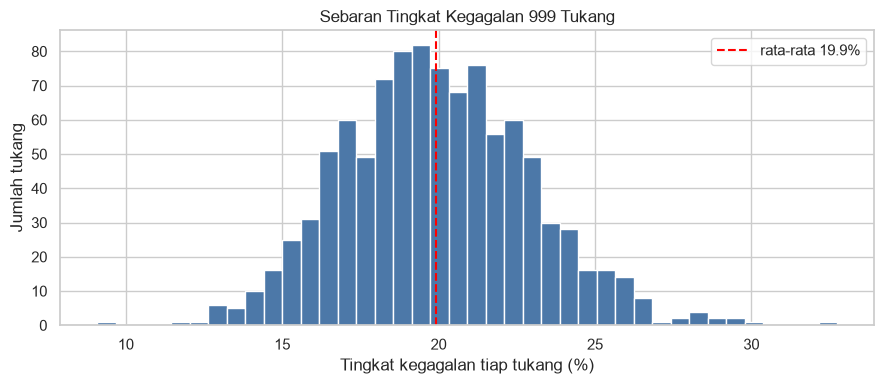

In [63]:
plt.figure(figsize=(9, 4))
plt.hist(per_tukang['tingkat'] * 100, bins=40, color='#4C78A8', edgecolor='white')
plt.axvline(p_rata * 100, color='red', linestyle='--', linewidth=1.5,
            label='rata-rata %.1f%%' % (p_rata * 100))
plt.title('Sebaran Tingkat Kegagalan 999 Tukang')
plt.xlabel('Tingkat kegagalan tiap tukang (%)')
plt.ylabel('Jumlah tukang')
plt.legend()
plt.tight_layout()
plt.show()

- Histogram dipakai karena yang ingin dilihat adalah **bentuk sebaran** di antara 999 orang, bukan
peringkat tiap orang

- Rumus pembandingnya sederhana apabila semua tukang sama baiknya, sebaran hasil mereka masih akan
melebar karena kebetulan, sebesar **akar dari [p × (1−p) ÷ n]** = 0,0289

Yang teramati **0,0299** yang rasionya **1,034** sebaran hanya **3,4%** lebih lebar

In [64]:
# kalau bukan siapa, lalu apa?
komposisi = rakit[rakit['gagal']]['installation_status'].value_counts()
print(komposisi)
print()
print('Missing Parts : %.1f%%' % (komposisi.iloc[0] / komposisi.sum() * 100))
print('Damaged Panel : %.1f%%' % (komposisi.iloc[1] / komposisi.sum() * 100))

installation_status
Failed - Missing Parts    22639
Failed - Damaged Panel    15279
Name: count, dtype: int64

Missing Parts : 59.7%
Damaged Panel : 40.3%


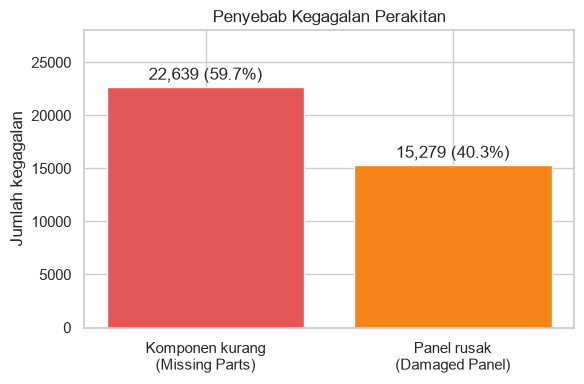

In [65]:
plt.figure(figsize=(6, 4))
bar = plt.bar(['Komponen kurang\n(Missing Parts)', 'Panel rusak\n(Damaged Panel)'],
              komposisi.values, color=['#E45756', '#F58518'])
plt.bar_label(bar, labels=['%s (%.1f%%)' % (f'{v:,}', v / komposisi.sum() * 100)
                           for v in komposisi.values], padding=3)
plt.title('Penyebab Kegagalan Perakitan')
plt.ylabel('Jumlah kegagalan')
plt.ylim(0, 28000)
plt.tight_layout()
plt.show()

dengan pertanyaan menanyakan **kategori barang** dapat dijawab datanya
lewat **jenis kegagalan**:

- **Komponen kurang — 22.639 (59,7%)** → masalah **kelengkapan paket** kurang baut, kurang
  engsel, atau paket memang tidak lengkap dari pemasok
- **Panel rusak — 15.279 (40,3%)** → masalah **penanganan barang** cara mengangkut, menumpuk, dan
  melindungi selama perjalanan

### **kategori apa yang paling sering gagal**?

- **Tidak ada kategori yang menonjol.** Ketujuhnya berada di rentang **19,60%–20,40%** — selisih hanya 0,80 poin persen 

- **Kegagalan 19,93% satu dari lima perakitan bersifat sistemik** Penyebabnya ada pada proses
 yang dilalui semua pesanan, yaitu penyiapan dan pengiriman barang sebelum tukang tiba

- Yang bisa ditunjuk bukan **siapa**, melainkan **apa**: **59,7% kegagalan karena komponen kurang**,
 40,3% karena panel rusak.

## 6.2 Apakah temuan-temuan ini saling berhubungan?

In [66]:
# apakah selisih hari berbeda antara perakitan yang berhasil dan yang gagal?
sah_uji = df_clean[df_clean['gap_hari'].notna()]
gap_berhasil = sah_uji[~sah_uji['gagal']]['gap_hari']
gap_gagal    = sah_uji[sah_uji['gagal']]['gap_hari']

print('rata-rata selisih, berhasil : %.4f hari' % gap_berhasil.mean())
print('rata-rata selisih, gagal    : %.4f hari' % gap_gagal.mean())
print('Mann-Whitney p-value        : %.4f' % mannwhitneyu(gap_berhasil, gap_gagal)[1])

rata-rata selisih, berhasil : 2.5048 hari
rata-rata selisih, gagal    : 2.5098 hari
Mann-Whitney p-value        : 0.6072


- **p = 0,6072 — tidak ada beda nyata.** Rata-ratanya 2,5048 hari lawan 2,5098 hari selisihnya
0,005 hari
- **Dugaan itu tidak terbukti.** Menunggu lima hari tidak membuat perakitan lebih mungkin gagal
daripada dirakit di hari yang sama
- **Menyelaraskan jadwal tidak akan menurunkan tingkat kegagalan.** Keduanya masalah terpisah
selisih hari adalah masalah **koordinasi jadwal** kegagalan perakitan adalah masalah
**kelengkapan dan kondisi barang**.

In [67]:
# seluruh uji hubungan yang sudah dijalankan
hasil_uji = pd.DataFrame([
    ['Selisih hari vs kegagalan', 'Mann-Whitney', 0.6072],
    ['Biaya jasa vs kegagalan', 'Mann-Whitney', 0.9332],
    ['Kegagalan antar kategori', 'Chi-square', 0.5588],
    ['Kegagalan antar tukang (999)', 'Chi-square', 0.0835],
    ['Selisih hari antar lokasi', 'Kruskal-Wallis',0.9490],
    ['Selisih hari antar bulan', 'Kruskal-Wallis',0.2060],
    ['Tanggal terbalik antar segmen', 'Chi-square', 0.1942],
], columns=['Yang diuji', 'Metode', 'p-value'])

hasil_uji['Kesimpulan'] = ['ADA hubungan' if p < 0.05 else 'TIDAK ada hubungan'
                           for p in hasil_uji['p-value']]
hasil_uji

,Yang diuji,Metode,p-value,Kesimpulan
0,Selisih hari vs kegagalan,Mann-Whitney,0.6072,TIDAK ada hubungan
1,Biaya jasa vs kegagalan,Mann-Whitney,0.9332,TIDAK ada hubungan
2,Kegagalan antar kategori,Chi-square,0.5588,TIDAK ada hubungan
3,Kegagalan antar tukang (999),Chi-square,0.0835,TIDAK ada hubungan
4,Selisih hari antar lokasi,Kruskal-Wallis,0.9490,TIDAK ada hubungan
5,Selisih hari antar bulan,Kruskal-Wallis,0.2060,TIDAK ada hubungan
6,Tanggal terbalik antar segmen,Chi-square,0.1942,TIDAK ada hubungan


**Tujuh uji, tidak satu pun menemukan hubungan.** Ini bukan kegagalan analisis — justru inilah
kesimpulannya.

Kalau masalahnya menumpuk di satu kategori, satu toko, atau satu tukang, akan ada yang bisa
ditunjuk dan diperbaiki secara khusus. Karena semuanya merata dan tidak saling berhubungan,
kesimpulannya hanya satu: **penyebabnya ada pada aturan yang berlaku di seluruh operasi**, dan
tiap masalah harus diperbaiki dengan caranya sendiri.

# 7. Kesimpulan dan Rekomendasi

## Kesimpulan

Di awal saya menyebut dua masalah, yaitu jadwal yang tidak sinkron dan komponen cacat atau hilang.
Dua-duanya terbukti, dan dua-duanya lebih dalam dari dugaan awal saya.

**Soal sinkronisasi jadwal**

Selisih rata-ratanya **2,51 hari**. Tapi yang penting bukan rata-ratanya, melainkan bentuk
sebarannya. Nilai 0 sampai 5 hari terisi rata sempurna, masing-masing sekitar **30.951 pesanan**
dengan simpangan di bawah 1%. Sebaran serata itu cuma muncul kalau tanggal dipilih tanpa aturan.

Yang memenuhi target 24 jam cuma **33,2%**. Sisanya **66,8%** melewatinya.

Jadi ini bukan masalah keterlambatan. Kedua jadwal disusun sendiri-sendiri dan tidak ada yang
menyatukannya.

**Soal kegagalan perakitan**

**19,93%** perakitan gagal, yaitu 37.918 dari 190.275. Satu dari lima. Penyebabnya **59,7%**
komponen kurang dan **40,3%** panel rusak.

Saya sudah periksa kategori, toko, saluran, bulan, dan tukang. Tidak ada satu pun yang menonjol.
Menurut saya penyebabnya ada di sistem, bukan di orang.

**Soal kualitas data**

**4.570 pesanan** bertanggal mustahil, dan semuanya berstatus Success. **1.893 nilai biaya**
tidak sah, dan cuma berisi dua nilai yang berulang. Dua-duanya terlalu rapi untuk kesalahan orang.

Kategori berantakan di **26,2% pesanan**, dan sempat membuat kategori terbesar salah tunjuk.

**Satu hal yang saya nyatakan terus terang**

Selisih hari dan kegagalan perakitan tidak berhubungan, p = **0,6072**. Memperbaiki jadwal tidak
akan menurunkan kegagalan. Keduanya masalah terpisah, dan saya tidak menggabungkannya cuma supaya
ceritanya lebih rapi.


## Rekomendasi

### 1. Satukan penjadwalan truk dan tukang dalam satu proses
*Logistics Sync . Head of Operations*

Jadwal perakitan ditentukan bersamaan dengan jadwal pengiriman waktu pesanan dibuat. Sistem cuma
menawarkan tanggal H+0 sampai H+1. Di luar itu perlu persetujuan khusus.

 **Target: naikkan porsi selisih <=1 hari dari 33,2% ke 60% dalam 6 bulan, lalu 75% dalam 12
 bulan.** Pada volume 2023, itu berarti sekitar **49.800 pesanan** pindah dari melewati target
 jadi memenuhi target.

Rekomendasi ini tidak minta tambahan truk atau tukang. Perakitan di hari yang sama sudah terjadi
**30.907 kali** tanpa aturan apa pun, jadi kapasitasnya sudah ada.

### 2. Periksa kelengkapan komponen sebelum barang keluar gudang
*Supplier QC . Procurement*

Tiap paket yang perlu dirakit diperiksa kelengkapannya sebelum dimuat, memakai daftar periksa per
SKU. Hasil pemeriksaannya dicatat sebagai kolom baru supaya bisa dianalisis nanti.

 **Target: turunkan tingkat kegagalan dari 19,93% ke 15% dalam 12 bulan**, terutama pada
 Missing Parts yang menyumbang 59,7%. Setara sekitar **9.300 kegagalan** lebih sedikit per
 tahun.

### 3. Catat identitas pemasok di tiap SKU
*Supplier QC . Procurement dan BI*

Dataset ini tidak punya kolom pemasok sama sekali, jadi pemasok dengan Missing Parts tertinggi
tidak bisa saya tunjuk. Kategori produk juga tidak bisa jadi penggantinya, karena beda antar
kategori terbukti tidak bermakna.

 **Target: supplier_id tercatat di 100% SKU baru dalam 3 bulan**, dan seluruh 1.500 SKU dalam
 6 bulan. Sesudah 6 bulan datanya terkumpul, kegagalan diuji ulang menurut pemasok.

### 4. Pasang validasi urutan tanggal waktu input
*Data Cleansing . IT*

Sistem menolak installation_date yang lebih awal daripada delivery_date waktu data dimasukkan.

 **Target: turunkan pesanan bertanggal mustahil dari 4.570 per tahun jadi 0 dalam 3 bulan.**

Langkah nolnya, konfirmasi dulu ke pemilik data apakah delivery_date berarti tanggal barang tiba
atau tanggal dokumen ditutup di sistem.

### 5. Telusuri dua nilai biaya baku, lalu batasi nilai yang sah
*Data Cleansing . IT dan Finance*

Telusuri proses yang menghasilkan nilai **-150.000** dan **99.900.000**, lalu batasi assembly_fee
supaya cuma menerima 0 atau nilai dalam daftar tarif resmi 50.000 sampai 250.000.

 **Target: turunkan catatan biaya tidak sah dari 1.893 per tahun jadi 0 dalam 3 bulan.**

Dampaknya pada pelaporan: rata-rata biaya per pesanan turun dari **404.446 jadi 94.835**,
dua-duanya dihitung dari seluruh pesanan. Kalau dihitung cuma dari pesanan yang benar-benar
memakai jasa rakit, tarif rata-ratanya **150.073**.
